In [1]:
# MLE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("loan_approved.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [6]:
df.loc[df['Gender'].isnull()==True]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
126,LP001448,NaN,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
171,LP001585,NaN,Yes,3+,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N


In [7]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [8]:
# 3 ways to handle NULL VALUES -- 1. loc  2. fillna  3. replace

df.loc[df['Gender'].isnull(),'Gender']="Male"

df['Gender'].fillna("Male",inplace=True)

df['Gender'].replace(np.nan, "Male", inplace=True)

In [9]:
df.loc[df['Gender'].isnull()==True]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


In [10]:
print(df['Married'].value_counts())
df.loc[df['Married'].isnull()==True]
df.loc[df['Married'].isnull(),'Married']="Yes"
df.loc[df['Married'].isnull()==True]

Married
Yes    398
No     213
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


In [11]:
print(df.Dependents.value_counts())
df.loc[df['Dependents'].isnull(),'Dependents']="0"
df.loc[df['Dependents'].isnull()==True]

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


In [12]:
print(df['Self_Employed'].value_counts())
df.loc[df['Self_Employed'].isnull(),'Self_Employed']="No"
df.loc[df['Self_Employed'].isnull()==True]

Self_Employed
No     500
Yes     82
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


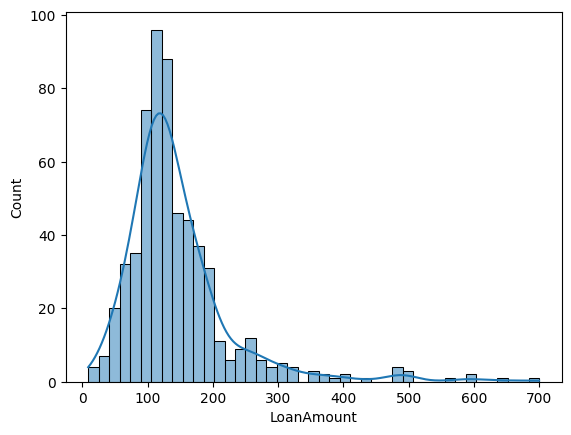

In [13]:
df['LoanAmount'].value_counts()  # continuous
sns.histplot(df['LoanAmount'],kde=True)  # not following ND -- go with median
df.loc[df['LoanAmount'].isnull(),'LoanAmount'] = df['LoanAmount'].median() 
df.loc[df['LoanAmount'].isnull()==True]

In [14]:
print(df['Loan_Amount_Term'].value_counts())  # continuous but after domain analysis it is better to go with 360.0 months
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term'] = 360.0
df.loc[df['Loan_Amount_Term'].isnull()==True]

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


In [15]:
print(df.Credit_History.value_counts())
df.loc[df['Credit_History'].isnull(),'Credit_History']=1.0
df.loc[df['Credit_History'].isnull()==True]

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


In [16]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  614 non-null    object 
 2   Married                 614 non-null    object 
 3   Dependents              614 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           614 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              614 non-null    float64
 9   Loan_Amount_Term        614 non-null    float64
 10  Credit_History          614 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# OUTLIERS

<Axes: xlabel='ApplicantIncome'>

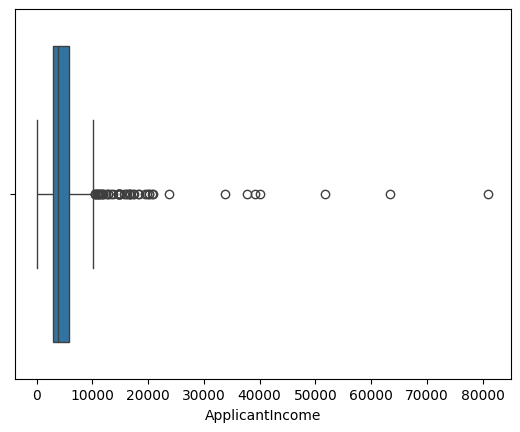

In [18]:
# To check outlier presence -- BOXPLOT
sns.boxplot(x=df['ApplicantIncome'])

In [19]:
# IQR METHOD
Q1 = df['ApplicantIncome'].quantile(0.25)
Q3 = df['ApplicantIncome'].quantile(0.75)
print(Q1,Q3)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
df.loc[df['ApplicantIncome']>upper_limit]
df.loc[df['ApplicantIncome']>upper_limit,'ApplicantIncome'] = df['ApplicantIncome'].median()
df.loc[df['ApplicantIncome']>upper_limit]

2877.5 5795.0
2917.5
-1498.75
10171.25


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


<Axes: xlabel='CoapplicantIncome'>

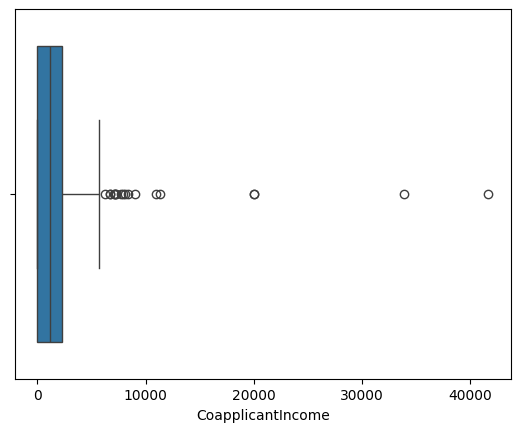

In [20]:
sns.boxplot(x=df['CoapplicantIncome'])

In [21]:
# IQR METHOD
Q1 = df['CoapplicantIncome'].quantile(0.25)
Q3 = df['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
df.loc[df['CoapplicantIncome']>upper_limit]
df.loc[df['CoapplicantIncome']>upper_limit,'CoapplicantIncome'] = df['CoapplicantIncome'].median()
df.loc[df['CoapplicantIncome']>upper_limit]

2297.25
-3445.875
5743.125


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)


<Axes: xlabel='LoanAmount'>

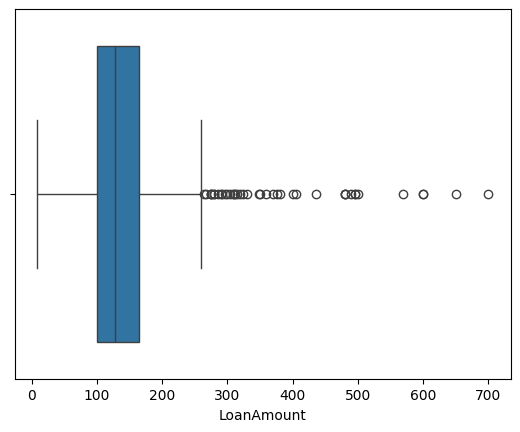

In [22]:
sns.boxplot(x=df['LoanAmount'])

In [29]:
from scipy.stats.mstats import winsorize
df['LoanAmount'] = winsorize(df['LoanAmount'], limits=(0,0.10))

<Axes: xlabel='LoanAmount'>

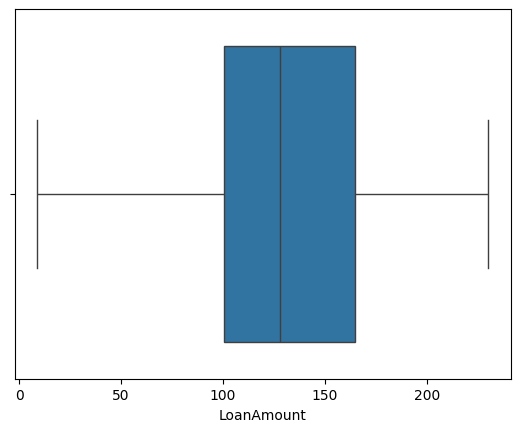

In [30]:
sns.boxplot(x=df['LoanAmount'])

In [31]:
df['Dependents'] = df['Dependents'].replace('3+','3')

In [32]:
df1 = df.copy()
df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,230.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y


In [33]:
df.drop('Loan_ID', axis=1,inplace=True)

In [34]:
x = df.drop('Loan_Status (Approved)', axis=1)
y = df['Loan_Status (Approved)']

In [35]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072.0,240.0,230.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban


In [36]:
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status (Approved), Length: 614, dtype: object

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [38]:
y

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,

In [39]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['0','1','2','3']])
x[['Dependents']] = oe.fit_transform(x[['Dependents']])

In [40]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['Not Graduate','Graduate']])
x[['Education']] = oe.fit_transform(x[['Education']])

In [41]:
x = pd.get_dummies(x,columns=['Gender','Married','Self_Employed','Property_Area'],drop_first=True)

In [42]:
x

,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.0,1.0,5849.0,0.0,128.0,360.0,1.0,True,False,False,False,True
1,1.0,1.0,4583.0,1508.0,128.0,360.0,1.0,True,True,False,False,False
2,0.0,1.0,3000.0,0.0,66.0,360.0,1.0,True,True,True,False,True
3,0.0,0.0,2583.0,2358.0,120.0,360.0,1.0,True,True,False,False,True
4,0.0,1.0,6000.0,0.0,141.0,360.0,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,1.0,2900.0,0.0,71.0,360.0,1.0,False,False,False,False,False
610,3.0,1.0,4106.0,0.0,40.0,180.0,1.0,True,True,False,False,False
611,1.0,1.0,8072.0,240.0,230.0,360.0,1.0,True,True,False,False,True
612,2.0,1.0,7583.0,0.0,187.0,360.0,1.0,True,True,False,False,True


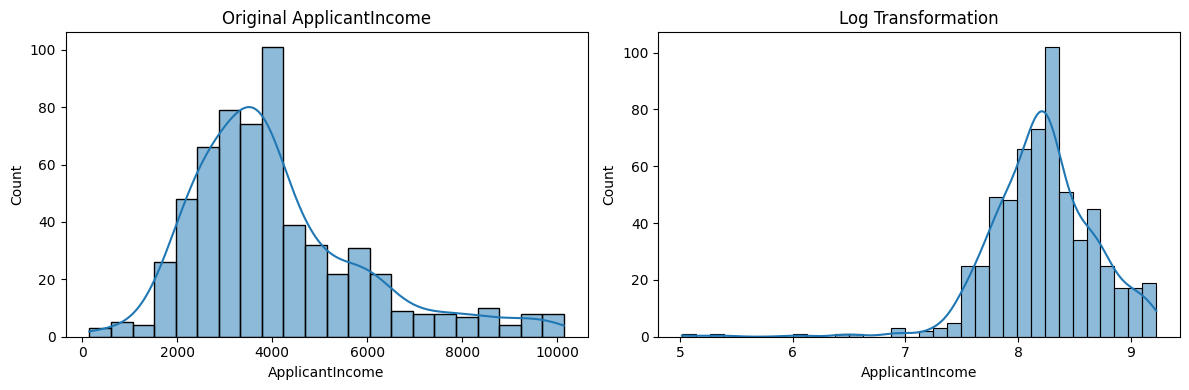

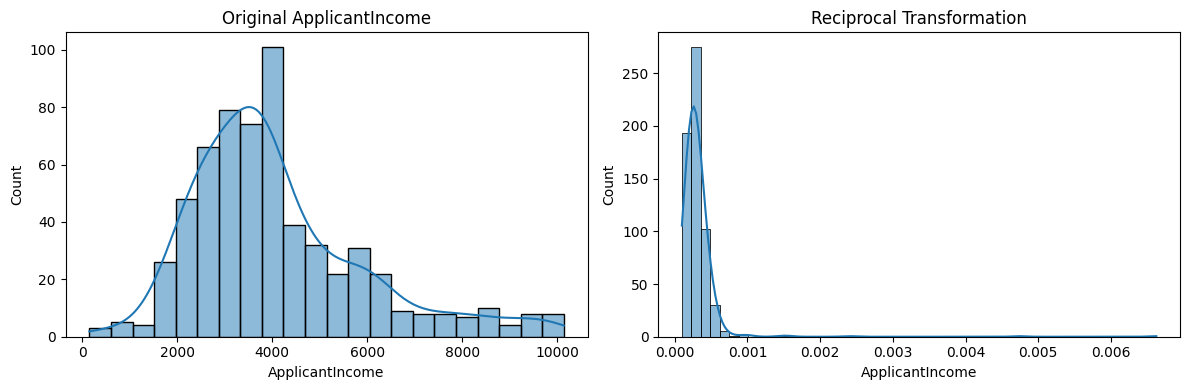

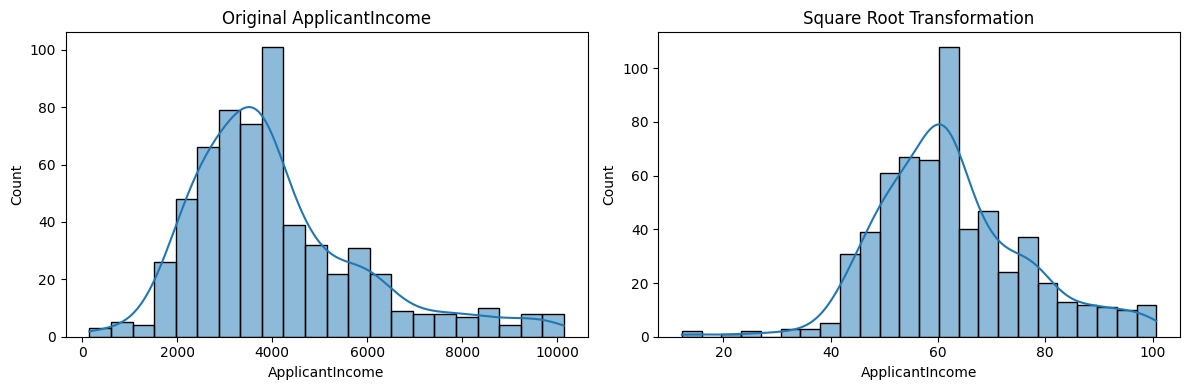

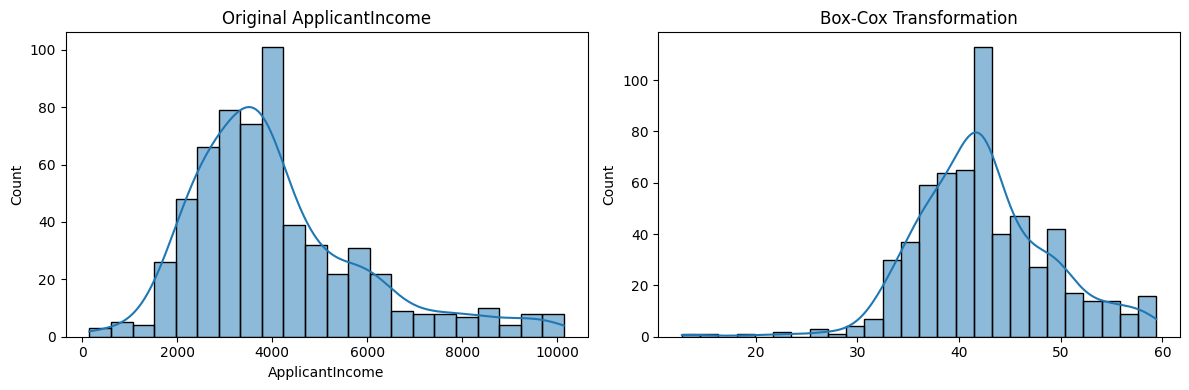

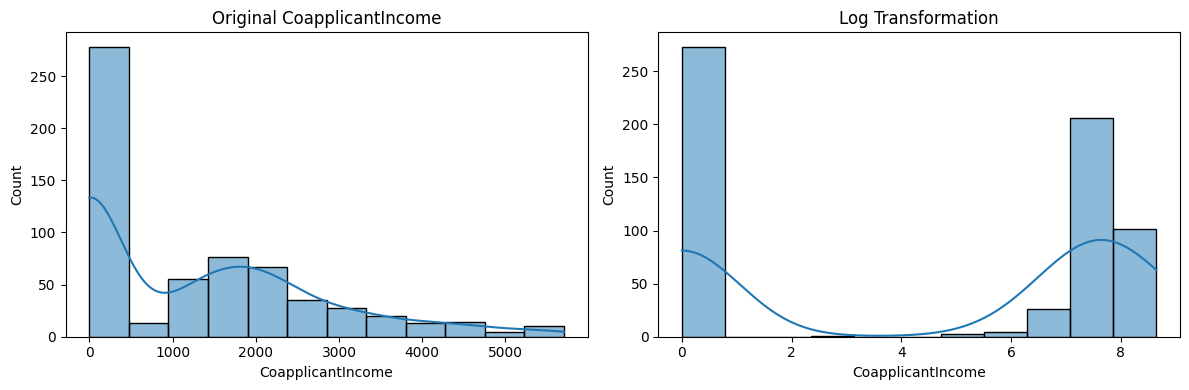

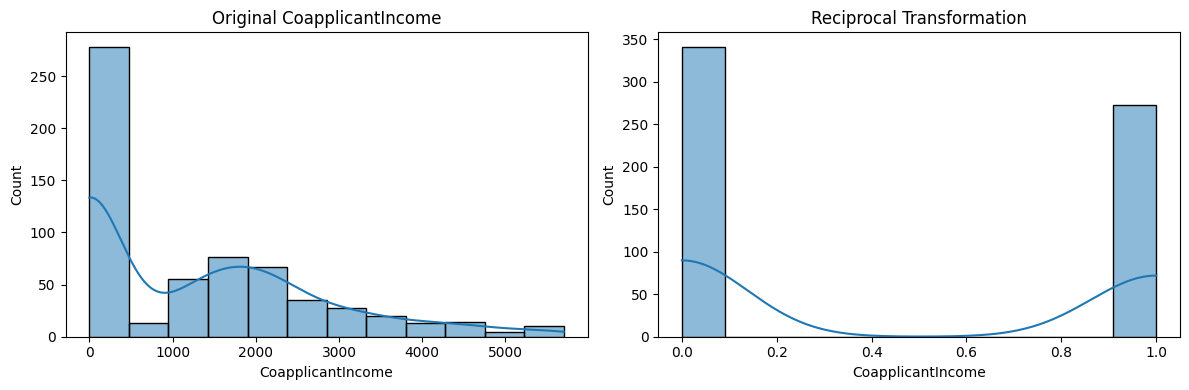

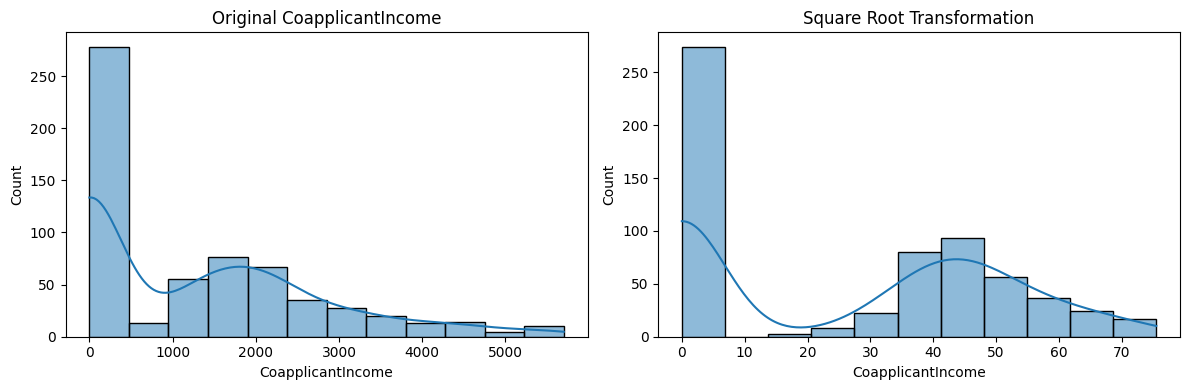

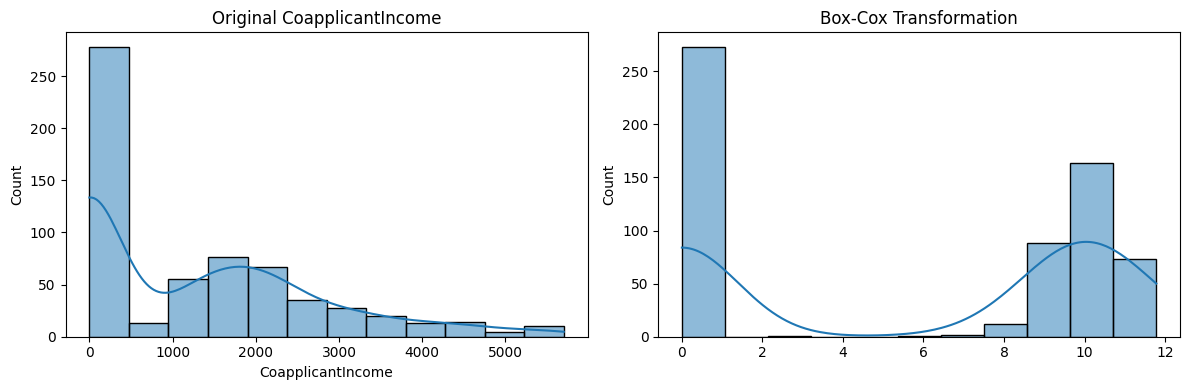

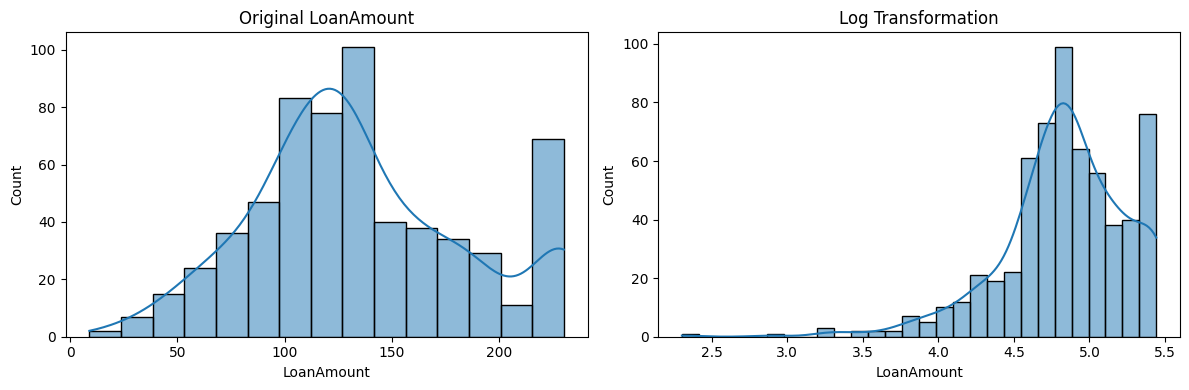

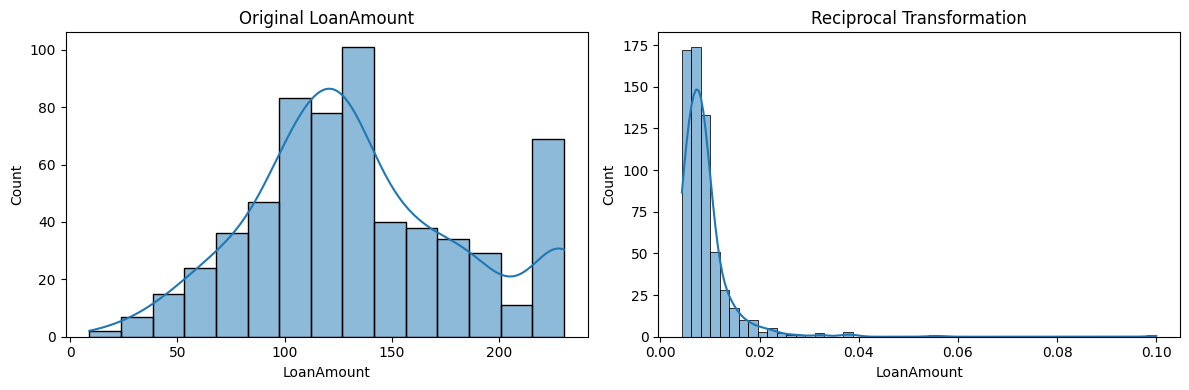

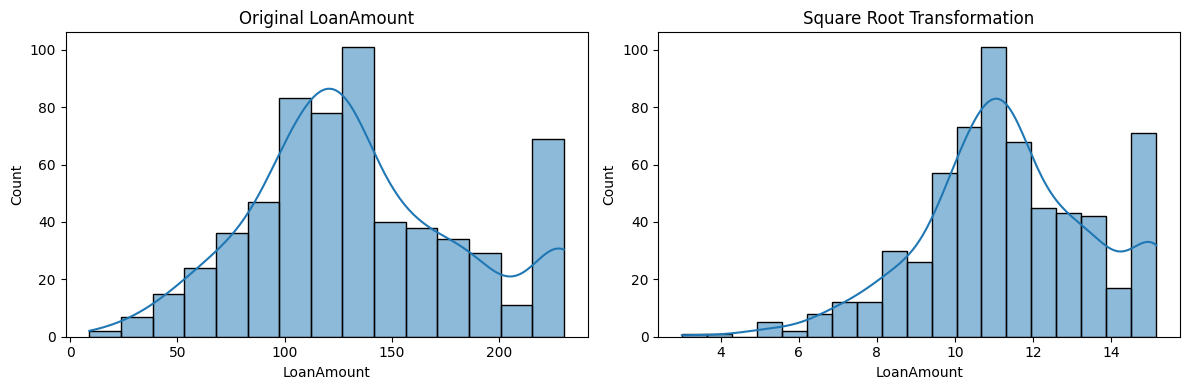

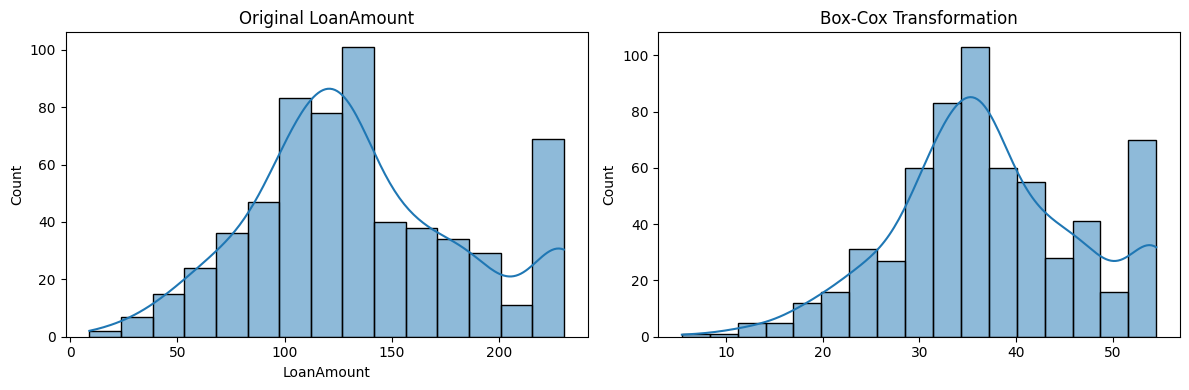

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in cols:

    transformations = [
        ("Log", np.log1p(df[col])),
        ("Reciprocal", 1/(df[col]+1)),
        ("Square Root", np.sqrt(df[col])),
        ("Box-Cox", boxcox(df[col]+1)[0])
    ]

    for name, data in transformations:

        plt.figure(figsize=(12,4))

        plt.subplot(1,2,1)
        sns.histplot(df[col], kde=True)
        plt.title(f"Original {col}")

        plt.subplot(1,2,2)
        sns.histplot(data, kde=True)
        plt.title(f"{name} Transformation")

        plt.tight_layout()
        plt.show()

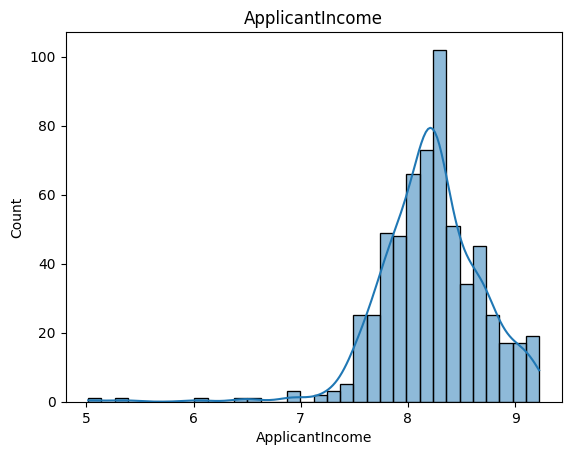

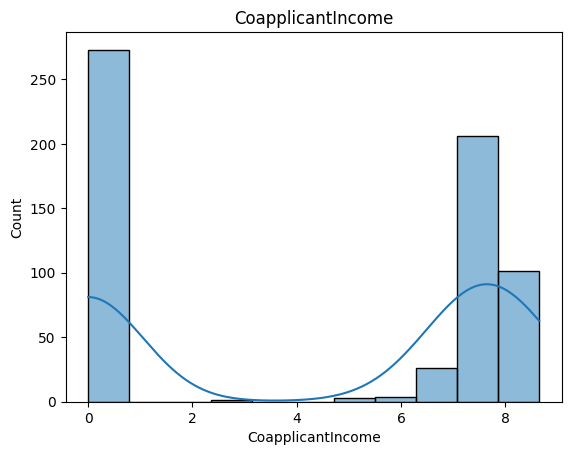

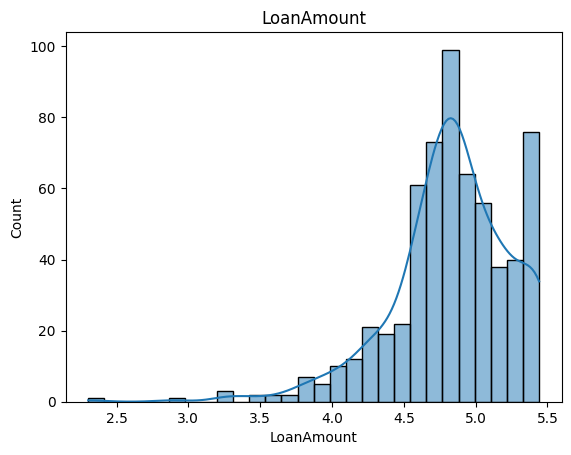

In [52]:
for col in Trans_cols:
    sns.histplot(x[col], kde=True)
    plt.title(col)
    plt.show()

In [50]:
# Transformation 
x['ApplicantIncome'] = np.log1p(x['ApplicantIncome']) # Highly right skewed
x['CoapplicantIncome'] = np.log1p(x['CoapplicantIncome'])  # Moderately right skewed
x['LoanAmount'] = np.log1p(x['LoanAmount'])

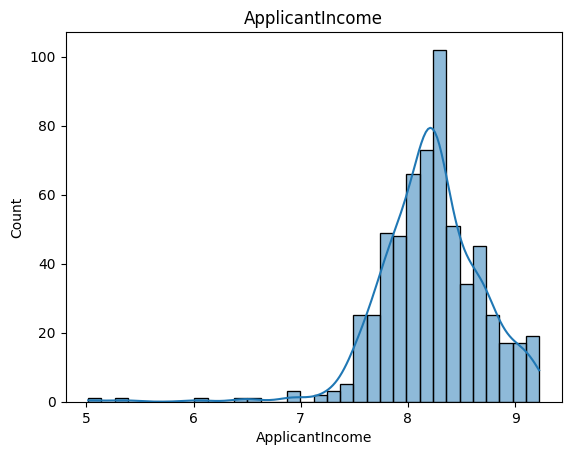

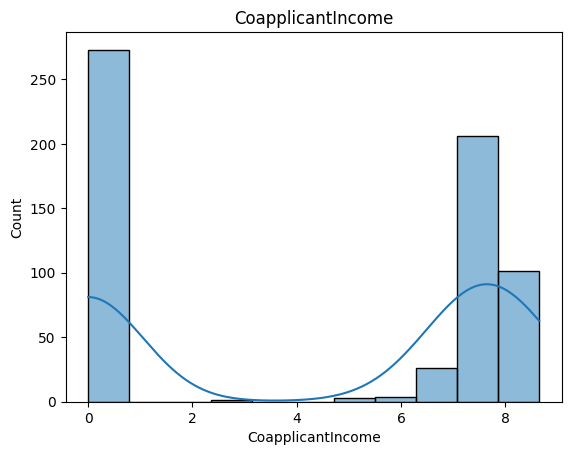

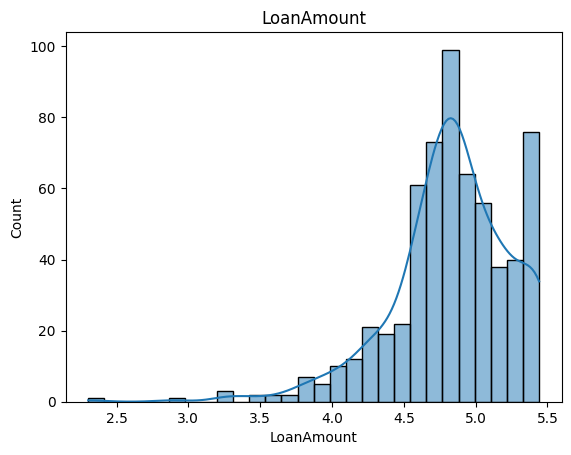

In [51]:
for col in Trans_cols:
    sns.histplot(x[col], kde=True)
    plt.title(col)
    plt.show()

In [40]:
x

,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.0,1.0,8.674197,0.000000,4.859812,360.0,1.0,True,False,False,False,True
1,1.0,1.0,8.430327,7.319202,4.859812,360.0,1.0,True,True,False,False,False
2,0.0,1.0,8.006701,0.000000,4.204693,360.0,1.0,True,True,True,False,True
3,0.0,0.0,7.857094,7.765993,4.795791,360.0,1.0,True,True,False,False,True
4,0.0,1.0,8.699681,0.000000,4.955827,360.0,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,1.0,7.972811,0.000000,4.276666,360.0,1.0,False,False,False,False,False
610,3.0,1.0,8.320448,0.000000,3.713572,180.0,1.0,True,True,False,False,False
611,1.0,1.0,8.996280,5.484797,5.442418,360.0,1.0,True,True,False,False,True
612,2.0,1.0,8.933796,0.000000,5.236442,360.0,1.0,True,True,False,False,True


In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount']
x[scale_cols] = scaler.fit_transform(x[scale_cols])

In [42]:
x

,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.0,1.0,0.970059,-1.110246,0.067307,360.0,1.0,True,False,False,False,True
1,1.0,1.0,0.450675,0.812342,0.067307,360.0,1.0,True,True,False,False,False
2,0.0,1.0,-0.451548,-1.110246,-1.482653,360.0,1.0,True,True,True,False,True
3,0.0,0.0,-0.770175,0.929704,-0.084164,360.0,1.0,True,True,False,False,True
4,0.0,1.0,1.024334,-1.110246,0.294469,360.0,1.0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,1.0,-0.523726,-1.110246,-1.312369,360.0,1.0,False,False,False,False,False
610,3.0,1.0,0.216658,-1.110246,-2.644603,180.0,1.0,True,True,False,False,False
611,1.0,1.0,1.656019,0.330485,1.445703,360.0,1.0,True,True,False,False,True
612,2.0,1.0,1.522943,-1.110246,0.958381,360.0,1.0,True,True,False,False,True
